In [16]:
from utils import generals
import pandas as pd
import os
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot
from scipy.fftpack import fft
from importlib import reload
import gc

origin = None
train = None
wws = None
hpc = None
hpt = None
esns = None
sensors = None
points = None

def check_init():
    global origin, train, wws, hpc, hpt, esns, sensors, points
    reload(generals)
    origin = generals.load_training()
    train = origin.dropna().copy() #757 righe in meno
    gc.collect() 
    esns = generals.ESN.copy()
    sensors = generals.SENSORS.tolist()

    wws = generals.get_shift('Cumulative_WWs', train)
    hpc = generals.get_shift('Cumulative_HPC_SVs', train)
    hpt = generals.get_shift('Cumulative_HPT_SVs', train)

    points = {"HPT": hpt, "HPC": hpc, "WWs": wws}

check_init()

       ESN  Cycles_Since_New  Snapshot  Cumulative_WWs  Cumulative_HPC_SVs  \
14738  102                 0         1               0                   0   
14745  102                10         1               0                   0   
14752  102                20         1               0                   0   
14760  102                30         1               0                   0   
14768  102                40         1               0                   0   
...    ...               ...       ...             ...                 ...   
29745  102             19960         1              19                   2   
29752  102             19970         1              19                   2   
29760  102             19980         1              19                   2   
29767  102             19990         1              19                   2   
29775  102             20000         1              19                   2   

       Cumulative_HPT_SVs  Sensed_Altitude  Sensed_Mach  Sensed

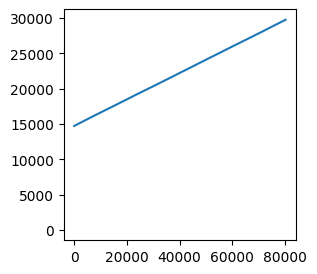

In [ ]:
check_init()
esn = 102
sensor = generals.SENSORS.Sensed_P25.value
snap = 1
cumsum = df[sensor].cumsum()
df = generals.filter(generals.filter(train, "ESN", esn), "Snapshot", snap)
plt.figure(figsize=(3,3))
plt.plot(cumsum, df.index)
for p_idx, (plabel, p_data) in enumerate(points.items()):
    current_points = p_data.loc[p_data['ESN'] == esn]
    if not current_points.empty:
        plt.vlines(
            x=current_points.index,
            ymin=cumsum.min(),
            ymax=cumsum.max(),
            linestyles='dashed',
            label=plabel,
            alpha=0.9,
            linewidth=2
        )
plt.show()

### NOTA: La rolling window è nel file ROLLING

# Analisi nel tempo
- rolling window (ROLLING.ipynb)
- EWMA
- regressione